**File:** notebooks/augmentation_preview.ipynb  
**Owner:** Shamathmika

**Purpose:**  
Visually previews the Augraphy degradation pipeline defined in `data/augment.py`.  
Loads 5 clean images from `data/shabby/clean/`, applies `augment_image()` to each,  
and displays original vs augmented side by side. Also shows the output of each  
individual pipeline stage (InkBleed, LowInkPeriodicLines, DirtyDrum, Folding,  
Brightness/contrast) for visual inspection.

**Dependencies:**  
- `data/augment.py` 
- `data/shabby/clean/` (populated by `data/download_shabby.py`)  
- Pillow, matplotlib, augraphy

In [1]:
import os
import sys

# Colab setup
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/DocRestore"
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

Project root: /Users/shamathmika./Library/CloudStorage/GoogleDrive-shamathmika.shamathmika@sjsu.edu/My Drive/2nd Year/Spring 2026/CMPE 258/Project/doc-restore


In [2]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from data.augment import (
    apply_degradation,
    build_augmentation_pipeline,
    augment_image,
)
from augraphy.augmentations import (
    BleedThrough, Brightness, ColorPaper, DirtyDrum,
    Folding, InkBleed, Jpeg, LowInkPeriodicLines, Markup, SubtleNoise,
)
from augraphy import AugraphyPipeline

random.seed(42)
np.random.seed(42)

CLEAN_DIR = Path("data/shabby/clean")
N_SAMPLES = 5

In [3]:
# Load 5 clean images
exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
all_clean = sorted(p for p in CLEAN_DIR.iterdir() if p.suffix.lower() in exts)
sample_paths = random.sample(all_clean, min(N_SAMPLES, len(all_clean)))
print(f"Loaded {len(sample_paths)} images from {CLEAN_DIR}")

Loaded 5 images from data/shabby/clean


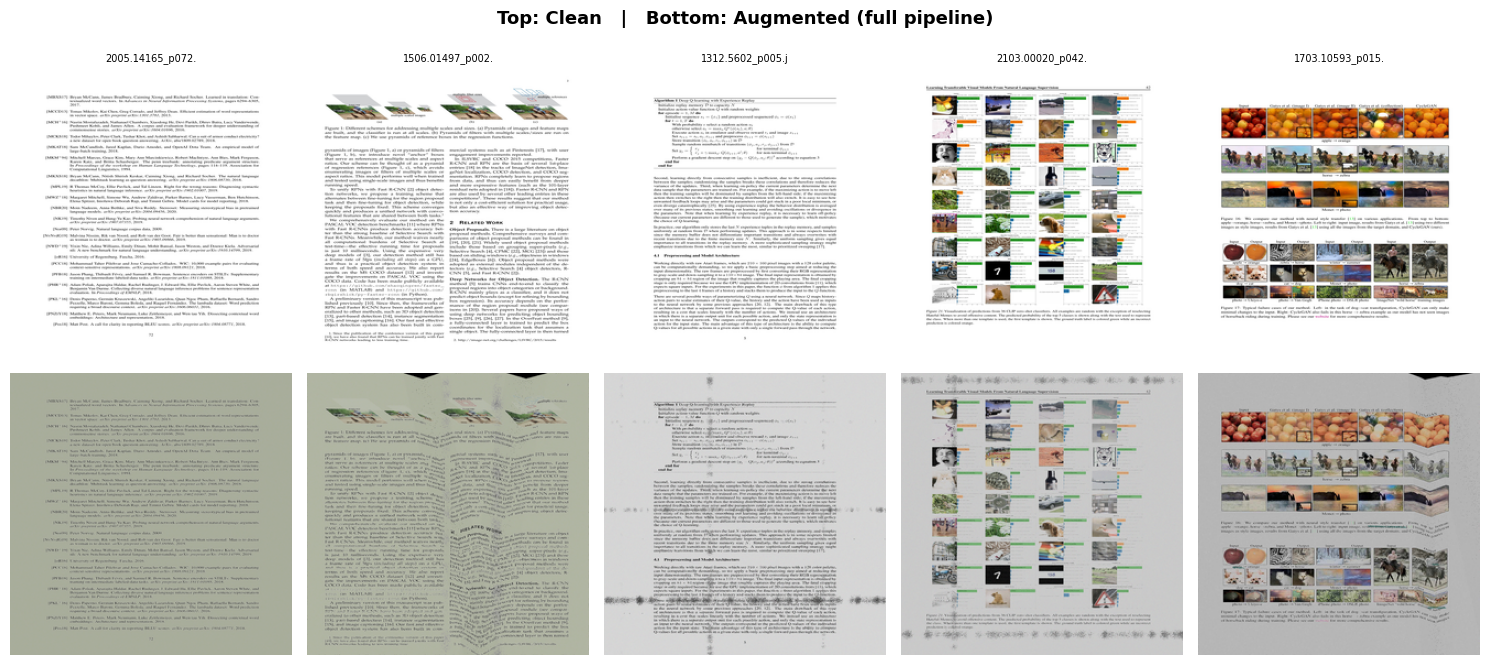

In [4]:
# Apply full pipeline and display original vs augmented side by side
pipeline = build_augmentation_pipeline()
thumb = (256, 256)

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(N_SAMPLES * 3, 7))
fig.suptitle("Top: Clean   |   Bottom: Augmented (full pipeline)", fontsize=13, fontweight="bold")

for col, path in enumerate(sample_paths):
    clean_img = Image.open(path).convert("RGB")

    img_bgr = np.array(clean_img)[:, :, ::-1].copy()
    deg_bgr = apply_degradation(img_bgr, pipeline)
    aug_img = Image.fromarray(deg_bgr[:, :, ::-1].copy())

    axes[0, col].imshow(clean_img.resize(thumb, Image.LANCZOS))
    axes[0, col].set_title(path.name[:16], fontsize=7)
    axes[0, col].axis("off")

    axes[1, col].imshow(aug_img.resize(thumb, Image.LANCZOS))
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

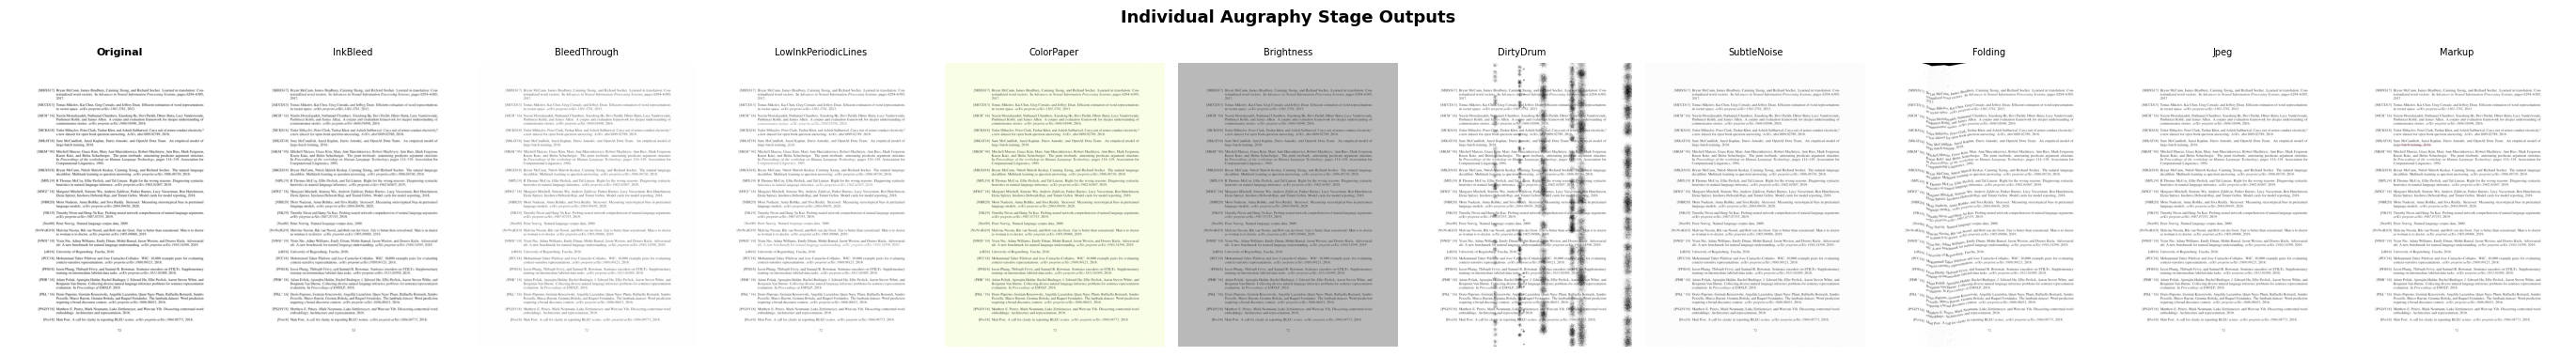

In [5]:
# Show output of each individual pipeline stage on one sample image
sample_bgr = np.array(Image.open(sample_paths[0]).convert("RGB"))[:, :, ::-1].copy()

stages = [
    ("InkBleed",            AugraphyPipeline(ink_phase=[InkBleed()],            paper_phase=[], post_phase=[])),
    ("BleedThrough",        AugraphyPipeline(ink_phase=[BleedThrough()],        paper_phase=[], post_phase=[])),
    ("LowInkPeriodicLines", AugraphyPipeline(ink_phase=[LowInkPeriodicLines()], paper_phase=[], post_phase=[])),
    ("ColorPaper",          AugraphyPipeline(ink_phase=[], paper_phase=[ColorPaper()],          post_phase=[])),
    ("Brightness",          AugraphyPipeline(ink_phase=[], paper_phase=[Brightness(brightness_range=(0.6, 0.75))], post_phase=[])),
    ("DirtyDrum",           AugraphyPipeline(ink_phase=[], paper_phase=[], post_phase=[DirtyDrum()])),
    ("SubtleNoise",         AugraphyPipeline(ink_phase=[], paper_phase=[], post_phase=[SubtleNoise()])),
    ("Folding",             AugraphyPipeline(ink_phase=[], paper_phase=[], post_phase=[Folding()])),
    ("Jpeg",                AugraphyPipeline(ink_phase=[], paper_phase=[], post_phase=[Jpeg()])),
    ("Markup",              AugraphyPipeline(ink_phase=[], paper_phase=[], post_phase=[Markup()])),
]

n_stages = len(stages)
fig, axes = plt.subplots(1, n_stages + 1, figsize=((n_stages + 1) * 2.5, 4))
fig.suptitle("Individual Augraphy Stage Outputs", fontsize=13, fontweight="bold")

axes[0].imshow(sample_bgr[:, :, ::-1])
axes[0].set_title("Original", fontsize=8, fontweight="bold")
axes[0].axis("off")

for i, (name, stage_pipeline) in enumerate(stages):
    result = stage_pipeline(sample_bgr.copy())
    if isinstance(result, dict):
        result = result.get("output", result.get("augmented", sample_bgr))
    axes[i + 1].imshow(result[:, :, ::-1])
    axes[i + 1].set_title(name, fontsize=7)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()